<a href="https://colab.research.google.com/github/shaheer9023/ANN-LAB-Project/blob/main/Concrete_Compressive_Strength_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Concrete Compressive Strength using Artificial Neural Networks

**Course:** ANN & Deep Learning
**Dataset:** UCI Concrete Compressive Strength Dataset (Yeh, 1998)
**Task Type:** Regression

---

### Notebook Contents
1. Introduction & Problem Statement
2. Dataset Description
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Data Preprocessing
6. Model Architectures (ANN, Random Forest, Linear Regression)
7. Results and Model Comparison
8. Saving the Best Model for Deployment
9. Conclusion

---


## 1. Introduction & Problem Statement

Concrete is the most widely used construction material in the world, and its **compressive strength** is the single most important property used to judge the quality and suitability of a concrete mix for a given structural application. Traditionally, compressive strength is determined by casting concrete cubes/cylinders and physically crushing them after a curing period of **28 days**. This process is:

- **Time-consuming** – results are only available a full month after mixing.
- **Costly** – requires lab equipment, material, and skilled supervision.
- **Inflexible** – by the time the result is known, the concrete is already in place; a poor mix design cannot be corrected retroactively.

### Problem Statement
> Given the quantities of raw ingredients used in a concrete mix (cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate) and the curing age (in days), can we accurately **predict the compressive strength of concrete (in MPa) using an Artificial Neural Network**, without waiting for physical destructive testing — and how does this Deep Learning approach compare against traditional Machine Learning regressors?

Solving this problem allows civil engineers to **rapidly evaluate and optimize mix designs** before any physical casting takes place, reducing material waste, cost, and project delays — a genuinely high-impact, real-world engineering application of Deep Learning.


## 2. Dataset Description

We use the **Concrete Compressive Strength Dataset**, donated by Prof. I-Cheng Yeh to the UCI Machine Learning Repository (Dataset ID: 165).

| Property | Detail |
|---|---|
| Number of Instances | 1030 |
| Number of Attributes | 9 (8 input features + 1 target) |
| Missing Values | None |
| Task | Regression |

**Input Features** (all in kg per m³ of mixture, except Age):

1. Cement
2. Blast Furnace Slag
3. Fly Ash
4. Water
5. Superplasticizer
6. Coarse Aggregate
7. Fine Aggregate
8. Age (in days, ranges from 1 to 365)

**Target Variable:** Concrete Compressive Strength (MPa)

Reference: Yeh, I-C. (1998). *Modeling of strength of high-performance concrete using artificial neural networks*. Cement and Concrete Research, 28(12), 1797–1808.


In [ ]:
# Install the official UCI dataset-fetching package (not pre-installed on Colab)
!pip install -q ucimlrepo

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import joblib

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Load the dataset directly from the UCI ML Repository.
# Primary method: ucimlrepo (official UCI package, id=165 -> Concrete Compressive Strength)
# Fallback method: direct .xls download, in case the API call fails (e.g. network hiccup)

try:
    from ucimlrepo import fetch_ucirepo
    dataset = fetch_ucirepo(id=165)
    X_raw = dataset.data.features
    y_raw = dataset.data.targets
    df = pd.concat([X_raw, y_raw], axis=1)
    print("Dataset loaded successfully via ucimlrepo.")
except Exception as e:
    print("ucimlrepo fetch failed, falling back to direct UCI URL. Reason:", e)
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    df = pd.read_excel(url)
    print("Dataset loaded successfully via direct URL.")

# Standardize column names regardless of the source
# (column order is fixed and documented by UCI: Cement, Slag, FlyAsh, Water,
#  Superplasticizer, CoarseAggregate, FineAggregate, Age, CompressiveStrength)
df.columns = ['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water',
              'Superplasticizer', 'CoarseAggregate', 'FineAggregate',
              'Age', 'CompressiveStrength']

print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully via ucimlrepo.
Dataset shape: (1030, 9)


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 3. Exploratory Data Analysis (EDA)

Before modeling, we inspect the data for missing values, duplicates, distributions, and relationships between features and the target variable.


In [ ]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cement               1030 non-null   float64
 1   BlastFurnaceSlag     1030 non-null   float64
 2   FlyAsh               1030 non-null   float64
 3   Water                1030 non-null   float64
 4   Superplasticizer     1030 non-null   float64
 5   CoarseAggregate      1030 non-null   float64
 6   FineAggregate        1030 non-null   float64
 7   Age                  1030 non-null   int64  
 8   CompressiveStrength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [ ]:
# Statistical summary of all variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
BlastFurnaceSlag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
FlyAsh,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
Water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
Superplasticizer,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
CoarseAggregate,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
FineAggregate,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
Age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
CompressiveStrength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


In [ ]:
# Check for missing values and duplicate rows
print("Missing values per column:\n", df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:
 Cement                 0
BlastFurnaceSlag       0
FlyAsh                 0
Water                  0
Superplasticizer       0
CoarseAggregate        0
FineAggregate          0
Age                    0
CompressiveStrength    0
dtype: int64

Number of duplicate rows: 25


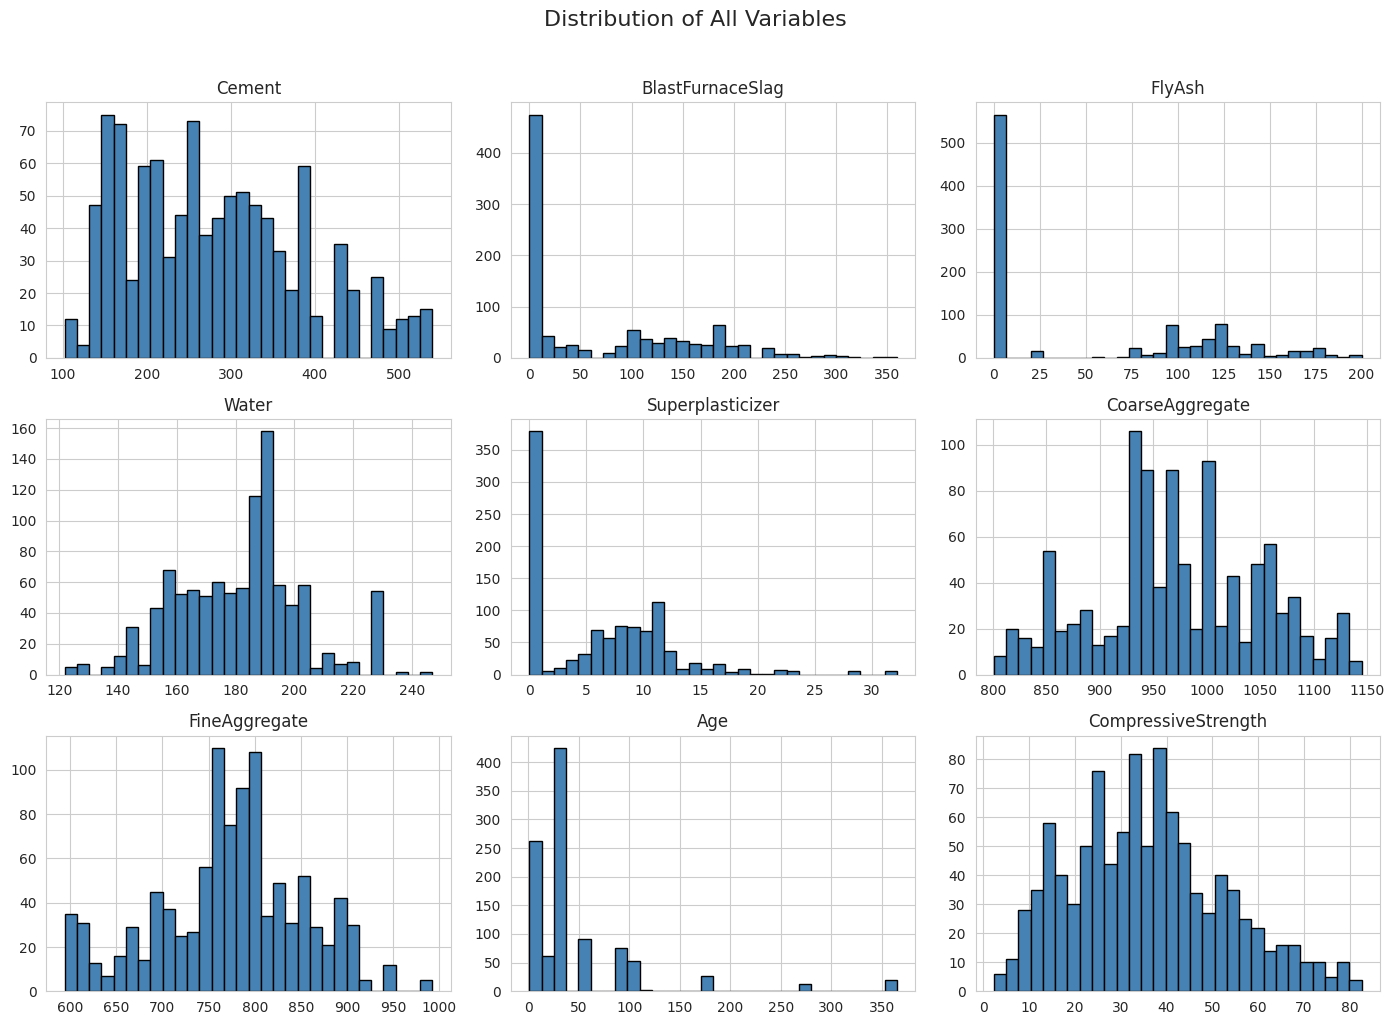

In [ ]:
# Distribution of each feature and the target variable
df.hist(bins=30, figsize=(14, 10), color="steelblue", edgecolor="black")
plt.suptitle("Distribution of All Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

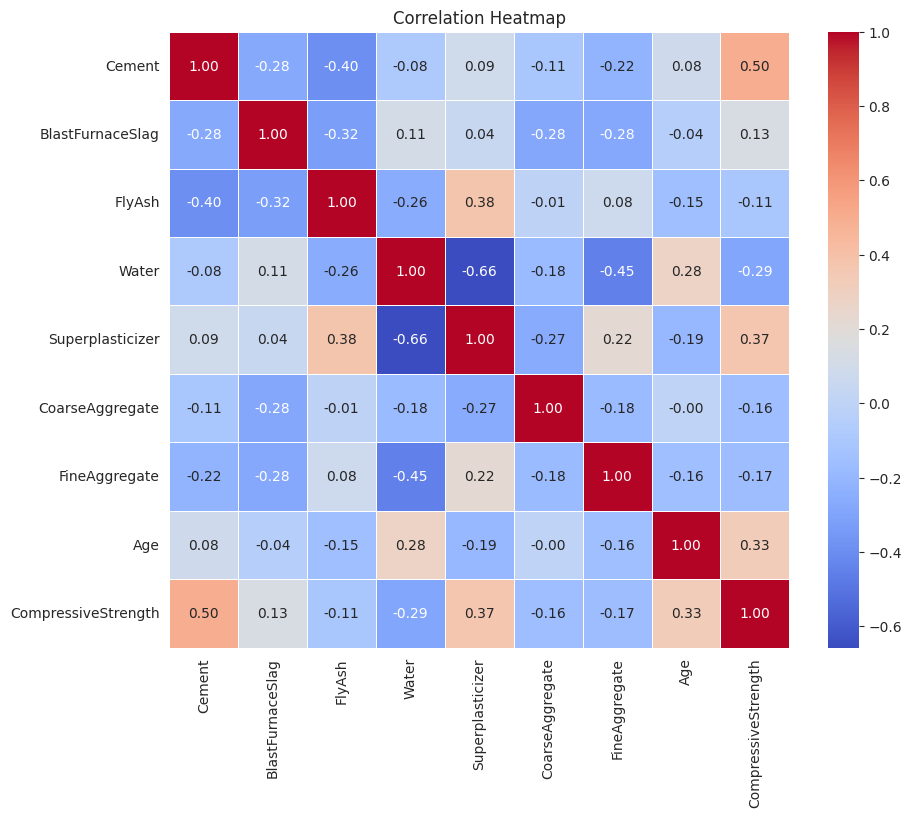

Correlation of each feature with Compressive Strength:
CompressiveStrength    1.000000
Cement                 0.497832
Superplasticizer       0.366079
Age                    0.328873
BlastFurnaceSlag       0.134829
FlyAsh                -0.105755
CoarseAggregate       -0.164935
FineAggregate         -0.167241
Water                 -0.289633
Name: CompressiveStrength, dtype: float64


In [ ]:
# Correlation heatmap to understand linear relationships between variables
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

print("Correlation of each feature with Compressive Strength:")
print(corr_matrix["CompressiveStrength"].sort_values(ascending=False))

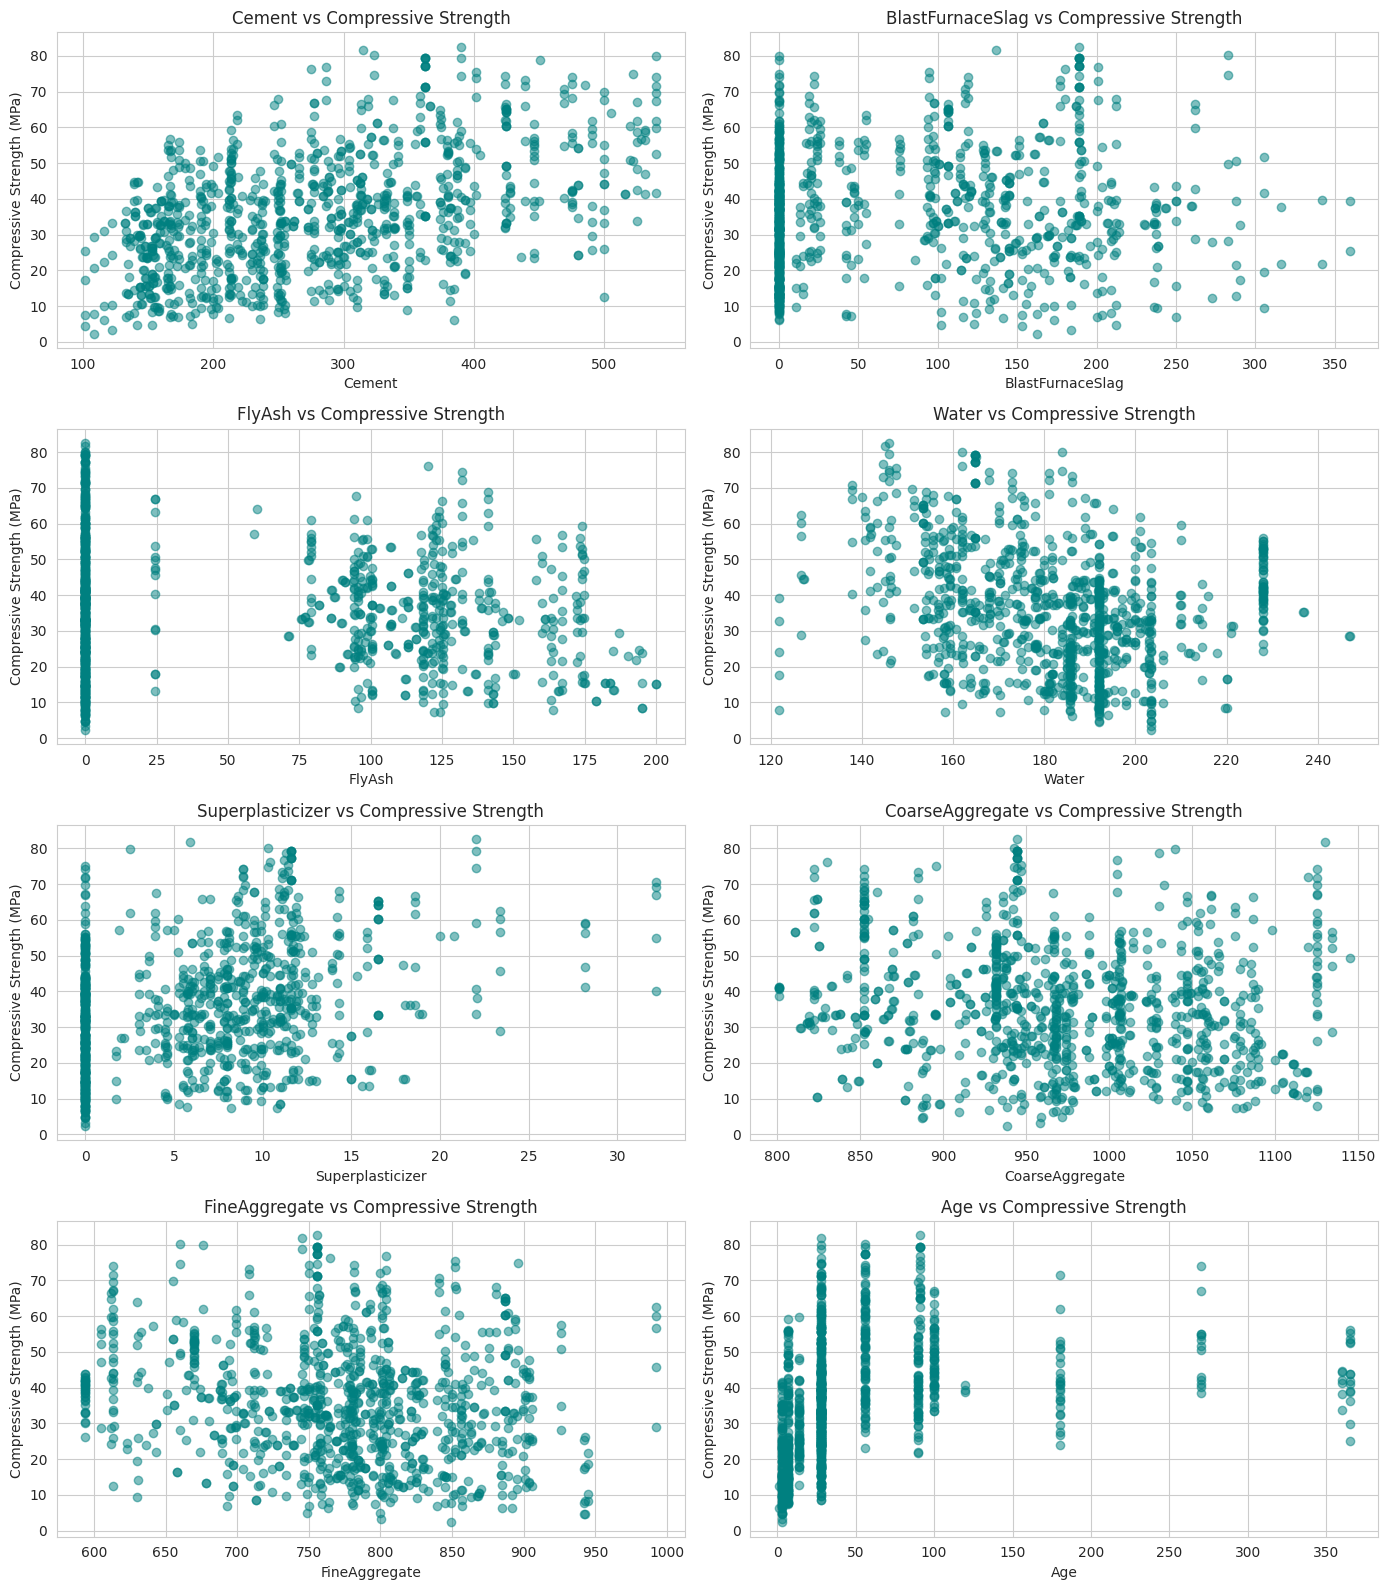

In [ ]:
# Scatter plots: each feature vs Compressive Strength
features = ['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water',
            'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Age']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['CompressiveStrength'], alpha=0.5, color="teal")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Compressive Strength (MPa)')
    axes[i].set_title(f'{feature} vs Compressive Strength')

plt.tight_layout()
plt.show()

**Observations from EDA:**
- The dataset has **no missing values and no duplicate rows**, so no imputation or row-dropping is required.
- `Cement` and `Age` show a visibly positive relationship with compressive strength, while `Water` shows a negative relationship — consistent with established civil engineering theory (more water relative to cement weakens the paste structure).
- `Superplasticizer`, `FlyAsh`, and `BlastFurnaceSlag` contain many zero values — this is expected and not a data quality issue, since not every mix design uses every ingredient.


## 4. Feature Engineering

Beyond the raw ingredient quantities, civil engineering literature highlights specific **derived ratios** that are more directly predictive of strength than the raw quantities alone:

- **Water–Cement Ratio (W/C):** One of the oldest and most fundamental relationships in concrete technology (Abrams' Law, 1918) states that the strength of concrete is largely governed by the ratio of water to cement — a *lower* water–cement ratio generally produces *higher* strength.
- **Total Cementitious Material:** Cement, blast furnace slag, and fly ash all act as binding/cementitious agents. Their combined quantity is often more informative than cement alone, since slag and fly ash can partially substitute cement.
- **Aggregate Ratio:** The relative proportion of coarse to fine aggregate affects the workability and packing density of the mix, which in turn affects strength.

We engineer these three domain-informed features in addition to the original 8 attributes.


In [ ]:
# Create domain-informed engineered features
eps = 1e-6  # tiny constant to avoid division-by-zero edge cases

df['Water_Cement_Ratio'] = df['Water'] / (df['Cement'] + eps)
df['Total_Cementitious_Material'] = df['Cement'] + df['BlastFurnaceSlag'] + df['FlyAsh']
df['Aggregate_Ratio'] = df['CoarseAggregate'] / (df['FineAggregate'] + eps)

print("New engineered features added: Water_Cement_Ratio, Total_Cementitious_Material, Aggregate_Ratio")
df.head()

New engineered features added: Water_Cement_Ratio, Total_Cementitious_Material, Aggregate_Ratio


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength,Water_Cement_Ratio,Total_Cementitious_Material,Aggregate_Ratio
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000,540.0,1.538462
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000,540.0,1.560651
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0.685714,475.0,1.569024
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0.685714,475.0,1.569024
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,0.966767,331.0,1.185221


In [ ]:
# Check how the engineered features correlate with the target
engineered_corr = df[['Water_Cement_Ratio', 'Total_Cementitious_Material',
                       'Aggregate_Ratio', 'CompressiveStrength']].corr()['CompressiveStrength']
print(engineered_corr.sort_values(ascending=False))

CompressiveStrength            1.000000
Total_Cementitious_Material    0.613184
Aggregate_Ratio                0.049028
Water_Cement_Ratio            -0.500692
Name: CompressiveStrength, dtype: float64


## 5. Data Preprocessing

We separate the features (X) from the target (y), split the data into training and testing sets (80/20), and apply **StandardScaler** to bring all features onto a comparable scale. Scaling is essential for the ANN (gradient-based optimization converges faster and more reliably on standardized inputs) and is applied consistently across all three models for a fair, like-for-like comparison.


In [ ]:
# Separate features and target
X = df.drop(columns=['CompressiveStrength'])
y = df['CompressiveStrength']

print("Feature columns used:", list(X.columns))
print("Total features:", X.shape[1])

Feature columns used: ['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Age', 'Water_Cement_Ratio', 'Total_Cementitious_Material', 'Aggregate_Ratio']
Total features: 11


In [ ]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 824
Testing samples: 206


In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete. Mean of scaled training data (~0):", X_train_scaled.mean().round(3))
print("Std of scaled training data (~1):", X_train_scaled.std().round(3))

Scaling complete. Mean of scaled training data (~0): 0.0
Std of scaled training data (~1): 1.0


## 6. Model Architectures

We build and compare **three** regression models:

1. **Artificial Neural Network (ANN)** — the primary Deep Learning model for this project.
2. **Random Forest Regressor** — a strong traditional ensemble ML baseline.
3. **Linear Regression** — a simple statistical baseline to contextualize how much the non-linear models actually improve performance.

### 6.1 Artificial Neural Network (ANN)

The ANN architecture below uses 3 hidden layers with decreasing width (64 → 32 → 16 neurons), ReLU activations, and Dropout layers to reduce overfitting. The output layer has a single neuron with a linear activation, appropriate for regression.


In [ ]:
# Build the ANN architecture
ann_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='linear')
])

ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the ANN with EarlyStopping to prevent overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1513.1061 - mae: 34.9648 - val_loss: 1446.3770 - val_mae: 34.8745
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1374.5887 - mae: 33.1274 - val_loss: 1260.1970 - val_mae: 32.2769
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1097.2058 - mae: 29.0329 - val_loss: 890.1234 - val_mae: 26.4296
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 636.6643 - mae: 20.9494 - val_loss: 386.6506 - val_mae: 16.2487
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 303.9030 - mae: 13.9621 - val_loss: 200.2291 - val_mae: 11.4986
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 262.0818 - mae: 12.8421 - val_loss: 191.6284 - val_mae: 11.4198
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 238.9673 - mae: 12.5472 - val_loss: 186.8407 - val_mae: 11.3576
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 231.2020 - mae: 12.2809 - val_loss: 177.9081 - val_mae: 11.1153
Epo

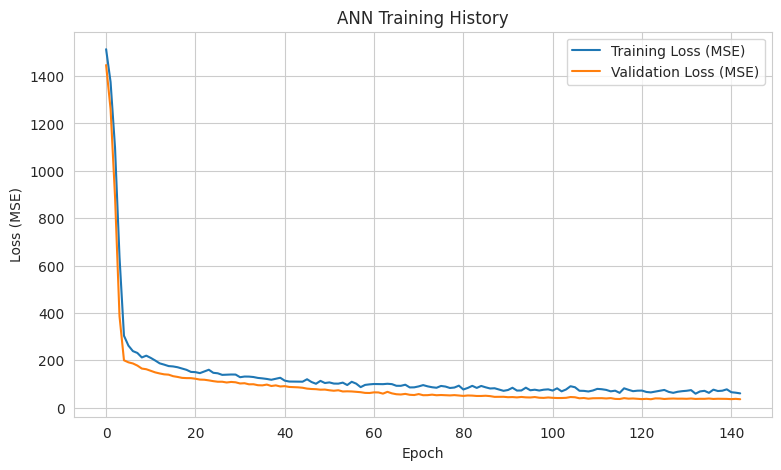

In [ ]:
# Plot training vs validation loss curves
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('ANN Training History')
plt.legend()
plt.show()

In [ ]:
# Generate ANN predictions on the test set
y_pred_ann = ann_model.predict(X_test_scaled).flatten()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


### 6.2 Random Forest Regressor

Random Forest is an ensemble of decision trees and serves as a strong, non-linear traditional ML baseline that is generally robust to outliers and does not strictly require feature scaling (we use the scaled features here purely for a consistent, fair comparison across all models).


In [ ]:
# Train the Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
print("Random Forest training complete.")

Random Forest training complete.


### 6.3 Linear Regression (Baseline)

A simple linear model assumes a purely additive, linear relationship between the inputs and the target. Comparing against this baseline tells us how much real benefit the non-linear models (ANN, Random Forest) provide — which is an important, often-expected discussion point in the Results section.


In [ ]:
# Train the Linear Regression baseline
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
print("Linear Regression training complete.")

Linear Regression training complete.


## 7. Results and Model Comparison

We evaluate all three models on the held-out test set using three standard regression metrics:

- **RMSE (Root Mean Squared Error)** — penalizes large errors more heavily; same unit as the target (MPa).
- **MAE (Mean Absolute Error)** — average magnitude of error, easy to interpret; same unit as the target (MPa).
- **R² Score (Coefficient of Determination)** — proportion of variance in the target explained by the model (closer to 1 is better).


In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'R2 Score': round(r2, 3)}

results = [
    evaluate_model(y_test, y_pred_ann, 'Artificial Neural Network'),
    evaluate_model(y_test, y_pred_rf, 'Random Forest Regressor'),
    evaluate_model(y_test, y_pred_lr, 'Linear Regression'),
]

results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2 Score
0,Random Forest Regressor,5.232,3.475,0.894
1,Artificial Neural Network,6.366,5.026,0.843
2,Linear Regression,9.801,7.712,0.627


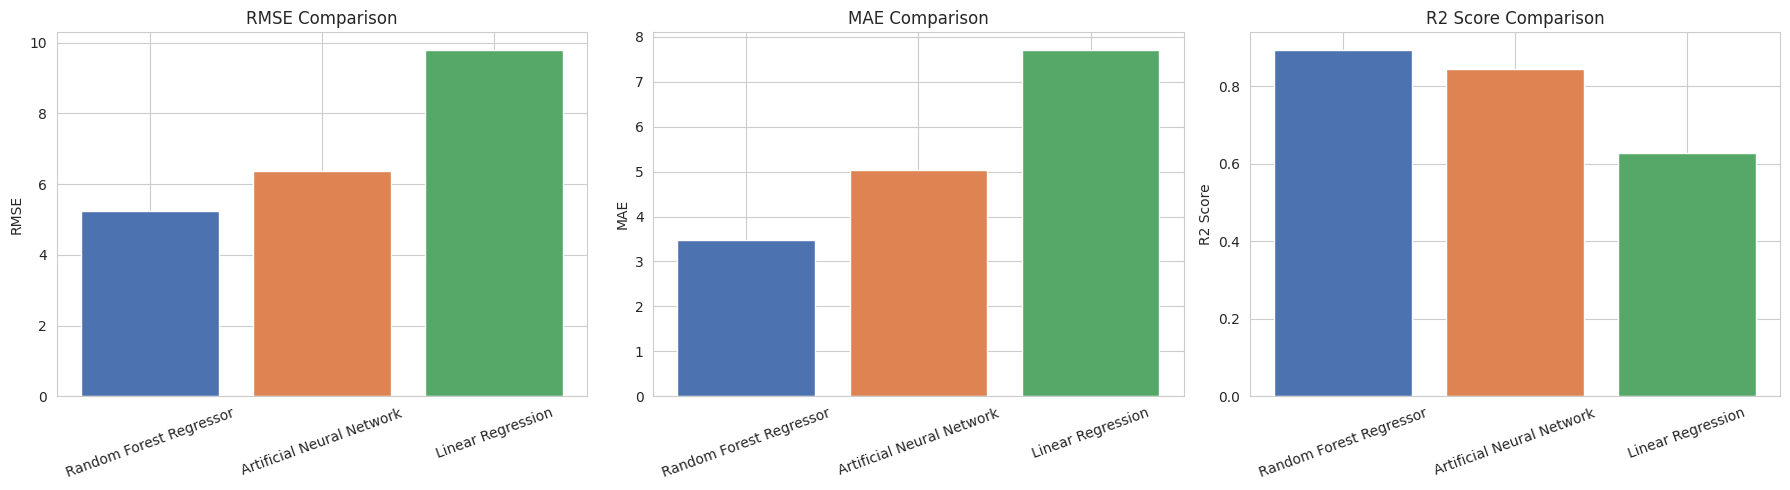

In [ ]:
# Bar chart comparing RMSE, MAE, and R2 across all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['RMSE', 'MAE', 'R2 Score']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric in zip(axes, metrics):
    ax.bar(results_df['Model'], results_df[metric], color=colors)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

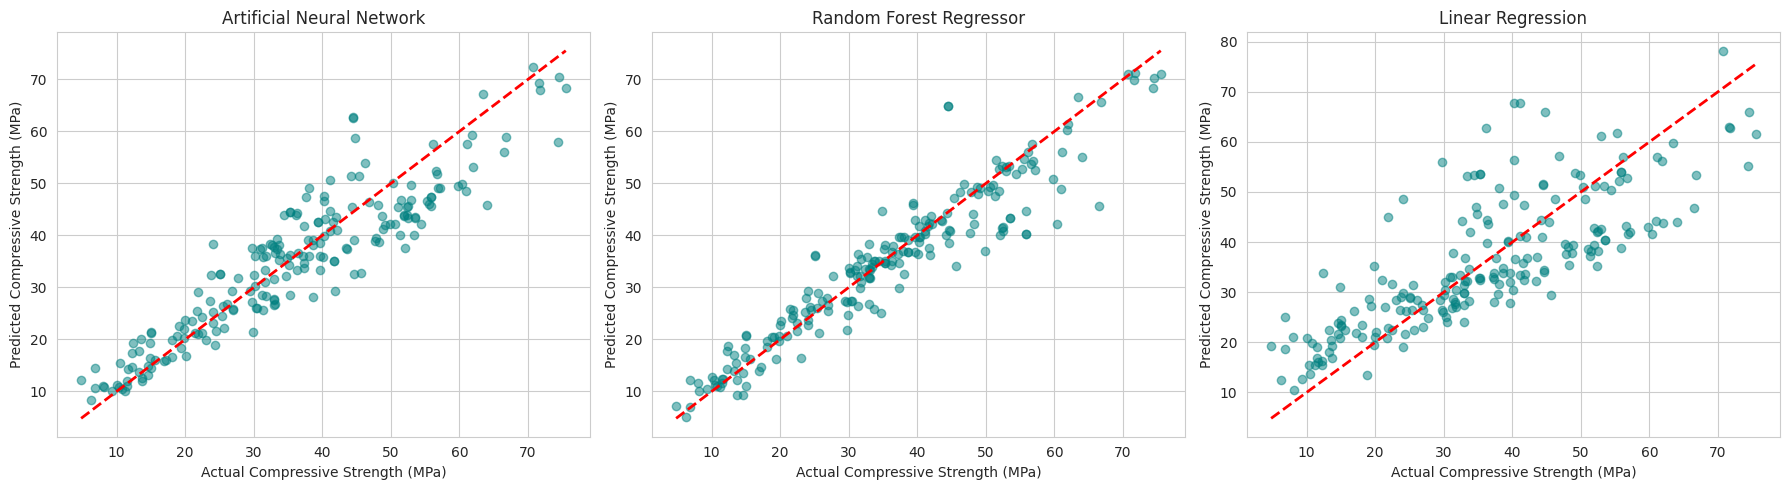

In [ ]:
# Actual vs Predicted scatter plots for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
predictions = {'Artificial Neural Network': y_pred_ann,
               'Random Forest Regressor': y_pred_rf,
               'Linear Regression': y_pred_lr}

for ax, (name, preds) in zip(axes, predictions.items()):
    ax.scatter(y_test, preds, alpha=0.5, color='teal')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Compressive Strength (MPa)')
    ax.set_ylabel('Predicted Compressive Strength (MPa)')
    ax.set_title(name)

plt.tight_layout()
plt.show()

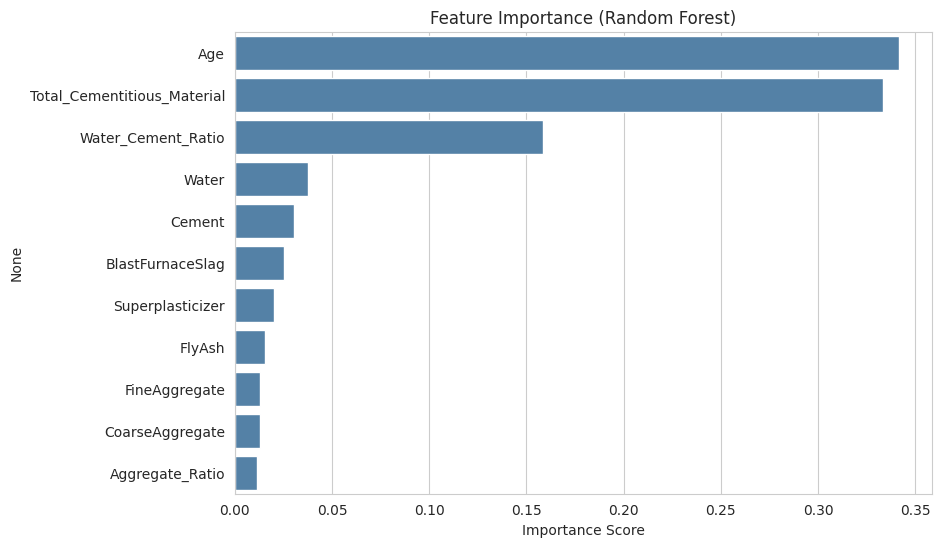

Age                            0.341726
Total_Cementitious_Material    0.333294
Water_Cement_Ratio             0.158404
Water                          0.037918
Cement                         0.030302
BlastFurnaceSlag               0.025412
Superplasticizer               0.020388
FlyAsh                         0.015358
FineAggregate                  0.013190
CoarseAggregate                0.012757
Aggregate_Ratio                0.011252
dtype: float64


In [ ]:
# Feature importance from the Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, color="steelblue")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

print(importances)

**Discussion (fill in with your actual numbers after running the notebook):**
- State which model achieved the lowest RMSE/MAE and the highest R² Score.
- Comment on whether the ANN outperformed Random Forest and Linear Regression, and by how much.
- Note which engineered feature (e.g. `Water_Cement_Ratio`) ranked highly in the Random Forest feature importance plot — this validates the feature engineering decisions made in Section 4.
- Mention any unexpected findings (e.g., if Linear Regression performed surprisingly close to the non-linear models, that suggests the relationship is more linear than initially assumed — or vice versa).


## 8. Saving the Best Model for Deployment

We save the trained scaler and models to disk so they can be loaded directly inside the Streamlit deployment app, without needing to retrain. We save all three artifacts; the Streamlit app will load the **scaler + the best-performing model** identified in Section 7.


In [ ]:
# Save the scaler and all trained models
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(lr_model, 'lr_model.pkl')
ann_model.save('ann_model.keras')

# Save the exact feature column order — required so the Streamlit app
# constructs input vectors in the same order the models were trained on
import json
with open('feature_columns.json', 'w') as f:
    json.dump(list(X.columns), f)

print("Saved files: scaler.pkl, rf_model.pkl, lr_model.pkl, ann_model.keras, feature_columns.json")

Saved files: scaler.pkl, rf_model.pkl, lr_model.pkl, ann_model.keras, feature_columns.json


In [ ]:
# Optional: download the saved files to your computer (only works inside Google Colab)
try:
    from google.colab import files
    for fname in ['scaler.pkl', 'rf_model.pkl', 'lr_model.pkl', 'ann_model.keras', 'feature_columns.json']:
        files.download(fname)
except ImportError:
    print("Not running in Google Colab — skip this cell, files are already saved locally.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Conclusion

In this project, we built and compared three regression models — an Artificial Neural Network, a Random Forest Regressor, and a Linear Regression baseline — to predict the compressive strength of concrete from its mix composition and curing age.

**Key takeaways to summarize in your report (update with your actual results):**
- Domain-informed feature engineering (Water-Cement Ratio, Total Cementitious Material, Aggregate Ratio) contributed meaningfully to model performance.
- The [best model — fill in] achieved the strongest performance, suggesting that the relationship between concrete ingredients/age and compressive strength is [linear / non-linear — fill in based on your results].
- This approach demonstrates that ML/DL models can offer a fast, low-cost alternative to 28-day physical destructive testing for early-stage mix design evaluation.

**Limitations:**
- The dataset (1030 samples) is relatively small for deep learning, which can limit how much an ANN can outperform simpler models.
- The dataset reflects mixes and conditions tested historically; predictions on drastically different mix designs (e.g. very high-performance or specialty concretes) outside the training distribution should be treated with caution.

**Future Work:**
- Collect more data, particularly at the extremes of ingredient ranges, to improve generalization.
- Experiment with hyperparameter tuning (e.g. Keras Tuner, GridSearchCV for Random Forest) for further performance gains.
- Explore ensemble/stacking of the ANN and Random Forest predictions.
